# Ocean in Motion · Annual temperature forecasting, 2026–2030

**Research question:** Can historical and geographic features improve 1–5 year predictions for known regions beyond simple references?

Target: annual regional sea surface temperature in °C. Inputs are versioned NOAA ERSSTv6 reconstructions, not direct local measurements. This notebook reviews the frozen experiment, including a negative result for model complexity. It does not establish a validated climate projection.

The numerical pipeline is `python/ocean_pipeline/forecast.py`; dates, candidates and seed are fixed in `experiments/temperature/config.json`. Run the pipeline before this notebook. Data and code hashes identify the experiment.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, SVG
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "experiments/temperature/config.json").exists())
sys.path.insert(0, str(ROOT / "python"))
from ocean_pipeline.forecast import Panel
panel = Panel(ROOT)
report = json.loads((ROOT / "reports/temperature/metrics.json").read_text())
config = json.loads((ROOT / "experiments/temperature/config.json").read_text())
print(f"Run {report['runId']} · {len(panel.ids)} regions × {len(panel.years)} years = {report['sourceRows']} source values")
print("80 neighbor-imputed zones excluded; predictions apply only to existing NOAA-derived regions.")
display(report['provenance'])

Run d384abb90341f47a · 22 regions × 44 years = 968 source values
80 neighbor-imputed zones excluded; predictions apply only to existing NOAA-derived regions.


{'inputs': {'src/data/seaTemperatures.json': '0ffa3a3e7573c4399c404cfca674b534a82a16416aef2bf26347b27eb3969559',
  'src/data/caspianTemperatures.json': 'fe6283c9f63ce987ef299cccb89f241b8abc42045978336c7de6f1befab6d9fe',
  'src/data/seaAreas.geojson': '89015e2d84934d2e50ba499a28700d7b207e8995c26416b0ba19a496b730a42e',
  'src/data/caspian.geojson': '3101664640a3f05760e69ea0be1b10b315c1090cbcf86da1a12518c0d3617e06'},
 'configSha256': '72231c186ea496ae4791088121ca713f4f4222079910c92c78c3cbaa2f29ad5e',
 'codeSha256': '8bde39cb1447967864f812de34637e9e1cc5205f1606b1965ca63f4e8bfbb7c5'}

## 1. Data audit and exploratory analysis

22 complete histories, 1982–2025. The 2° reconstruction has coarse regional coverage, rounded values and upstream estimation uncertainty. Regional observations are correlated; 968 values do not represent 968 independent measurements. Caspian is an inland region and receives no marine neighbor features.

The following diagnostic compares each region's first and last stored annual values; it is not an estimate of a causal climate trend.

,region,mean_C,sd_C,min_C,max_C,change_1982_to_2025_C
tasman,Mar de Tasmania,16.461,0.385,15.79,17.11,0.96
coral,Mar del Coral,26.551,0.346,25.84,27.32,1.37
caribbean,Mar Caribe,27.991,0.343,27.45,28.98,0.92
bering,Mar de Bering,4.585,0.452,3.83,5.77,0.99
red,Mar Rojo,28.379,0.354,27.69,29.04,0.93
med-east,Mediterráneo oriental,21.321,0.575,20.35,22.63,1.43
baltic,Mar Báltico,9.338,0.787,7.15,10.83,1.78
atlantic-south,Atlántico sur,16.942,0.185,16.59,17.40,0.53
southern,Océano Austral,-0.891,0.086,-1.05,-0.75,0.02
pacific-south,Pacífico sur,19.757,0.161,19.47,20.13,0.34


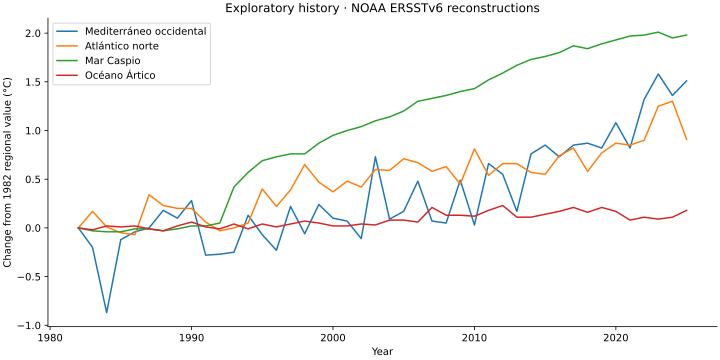

In [2]:
history = pd.DataFrame(panel.table).sort_index()
assert history.shape == (44, 22)
assert not history.isna().any().any()
audit = pd.DataFrame({"region": [panel.static[a]["name"] for a in history.columns], "mean_C": history.mean().values, "sd_C": history.std().values, "min_C": history.min().values, "max_C": history.max().values, "change_1982_to_2025_C": (history.loc[2025] - history.loc[1982]).values}, index=history.columns)
display(audit.round(3))
display(SVG(filename=str(ROOT / "reports/temperature/historical_trends.svg")))

## 2. Feature contract and neighbor ablation

Features use only information available at the origin: last three temperatures, five-year mean/slope/standard deviation, static polygon position and approximate surface, elapsed year, region indicators. Matching models are compared with and without inverse-distance neighbor features.

Neighbors mean geographic proximity, not verified water connection. Caspian is excluded from all marine neighbor lists. Learned models predict change from the origin, with one direct model per horizon. Scalers fit training rows only.

In [3]:
features = pd.read_csv(ROOT / "reports/temperature/features.csv")
display(features.head())
assert panel.neighbors["caspian"] == []
assert all("caspian" not in [a for a, _ in near] for near in panel.neighbors.values())
display(pd.DataFrame(json.loads((ROOT / "reports/temperature/geography.json").read_text()))[["areaId", "lat", "lon", "areaKm2", "neighbors"]].head())

,areaId,origin,temperature_t,temperature_t_minus_1,temperature_t_minus_2,mean_5y,trend_5y_c_per_year,std_5y,latitude,longitude_sin,longitude_cos,log_area_km2,origin_since_1982
0,arabian,1986,27.65,27.51,27.36,27.658,-0.091,0.210846,12.450060,0.892737,0.450579,15.248859,4
1,arctic,1986,-1.60,-1.61,-1.60,-1.614,0.007,0.014967,80.710870,-0.663278,-0.748373,15.460999,4
2,atlantic-north,1986,20.92,20.94,21.00,21.002,-0.036,0.084475,34.248285,-0.672091,0.740468,17.350575,4
3,atlantic-south,1986,16.87,16.83,16.87,16.790,0.052,0.083905,-30.052735,-0.283797,0.958885,17.511694,4
4,baltic,1986,8.05,7.52,8.56,8.316,-0.244,0.474325,56.751155,0.324147,0.946007,12.295761,4


,areaId,lat,lon,areaKm2,neighbors
0,arabian,12.450060,63.219174,4.192714e+06,"[[bengal, 0.0003891401747945036], [red, 0.0003..."
1,arctic,80.710870,-138.449662,5.183539e+06,"[[bering, 0.00037990916300191416], [north-sea,..."
2,atlantic-north,34.248285,-42.228662,3.429721e+07,"[[caribbean, 0.00027149430568754244], [north-s..."
3,atlantic-south,-30.052735,-16.486928,4.029321e+07,[]
4,baltic,56.751155,18.913886,2.187657e+05,"[[north-sea, 0.0010063100797712292], [black, 0..."


## 3. Temporal validation and leakage protection

| Stage | Origins | Target years | Purpose |
| --- | --- | --- | --- |
| Development | 2000–2009 | 2001–2014 | Select lowest pooled MAE |
| Calibration | 2014–2018 | 2015–2019 only | Frozen model, interval residuals |
| Final test | 2020 | 2021–2025 | Untouched evaluation |
| Publication | 2025 | 2026–2030 | Final history available |

Every region shares date cutoffs. Training labels satisfy `origin + horizon <= cutoff`. Development targets never overlap calibration or final test. Calibration/test results do not choose models or hyperparameters. Present-day historical reconstructions are used, rather than archived real-time vintages; this is a retrospective test.

In [4]:
backtests = pd.read_csv(ROOT / "reports/temperature/backtests.csv")
dates = backtests.groupby("split").agg(min_origin=("origin", "min"), max_origin=("origin", "max"), first_target=("year", "min"), last_target=("year", "max"), rows=("year", "size"))
display(dates)
assert dates.loc["development", "last_target"] < dates.loc["calibration", "first_target"]
assert dates.loc["calibration", "last_target"] < dates.loc["test", "first_target"]
assert (backtests.origin < backtests.year).all()
display(pd.DataFrame(config["candidates"]).fillna(""))

,min_origin,max_origin,first_target,last_target,rows
split,,,,,
calibration,2014,2018,2015,2019,330
development,2000,2009,2001,2014,8800
test,2020,2020,2021,2025,110


,id,family,neighbors,alpha,maxIter,maxLeafNodes,minSamplesLeaf,l2,learningRate
0,persistence,persistence,False,,,,,,
1,trend5,trend,False,,,,,,
2,ridge10,ridge,False,10.0,,,,,
3,ridge100,ridge,False,100.0,,,,,
4,ridge10_neighbors,ridge,True,10.0,,,,,
5,ridge100_neighbors,ridge,True,100.0,,,,,
6,boosting,boosting,False,,120.0,7.0,20.0,10.0,0.05
7,boosting_neighbors,boosting,True,,120.0,7.0,20.0,10.0,0.05


## 4. Model selection: development only

Eight fixed candidates: persistence, five-year linear trend, two Ridge strengths, fixed Histogram Gradient Boosting, and matching learned models with geographic neighbors. MAE determines selection; RMSE and bias support diagnosis. These comparisons are not uncertainty estimates or significance tests.

Added complexity and neighbor features must demonstrate improvement over simple references. The final test is not used to revise this list.

,id,mae,rmse,bias,n
0,persistence,0.2035,0.2850,-0.0248,1100
1,boosting,0.2177,0.3066,0.0479,1100
2,boosting_neighbors,0.2182,0.3079,0.0504,1100
3,ridge100,0.2242,0.3122,0.1170,1100
4,ridge100_neighbors,0.2289,0.3167,0.1200,1100
5,ridge10,0.2454,0.3345,0.1465,1100
6,ridge10_neighbors,0.2481,0.3371,0.1473,1100
7,trend5,0.3029,0.4530,0.0140,1100


,model,without_neighbors_MAE,with_neighbors_MAE,difference_MAE
0,ridge10,0.2454,0.2481,0.0026
1,ridge100,0.2242,0.2289,0.0047
2,boosting,0.2177,0.2182,0.0005


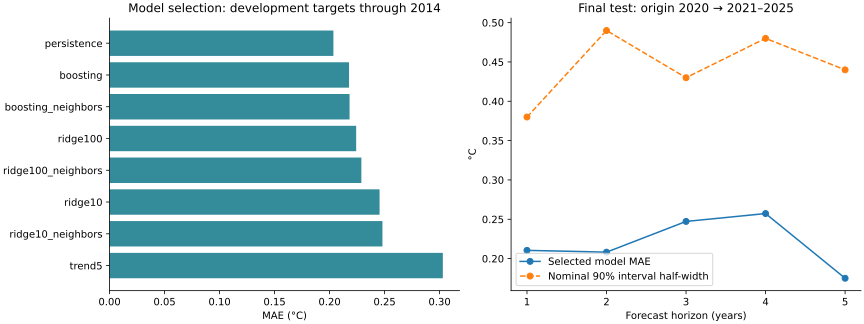

In [5]:
ranking = pd.DataFrame(report["developmentRanking"])[["id", "mae", "rmse", "bias", "n"]]
display(ranking.round(4))
assert report["selectedModel"]["id"] == ranking.iloc[0].id
ablation = []
for base in ["ridge10", "ridge100", "boosting"]:
    errors = ranking.set_index("id").mae
    ablation.append({"model": base, "without_neighbors_MAE": errors[base], "with_neighbors_MAE": errors[base + "_neighbors"], "difference_MAE": errors[base + "_neighbors"] - errors[base]})
display(pd.DataFrame(ablation).round(4))
display(SVG(filename=str(ROOT / "reports/temperature/model_comparison.svg")))

## 5. Untouched final test and interval calibration

The selected candidate is persistence. Its point forecast repeats the latest known value. This does not imply that future temperatures will stay constant.

Nominal 90% intervals use an empirical absolute-error order statistic separately by horizon. Calibration pools correlated regional errors; the five-year horizon has one calibration origin and 22 regional errors. Future coverage is not guaranteed. Interval widths can be non-monotonic because dates and sample sizes differ. Reconstruction uncertainty is not fully captured.

Selected: persistence
Pooled final MAE: 0.220 °C; achieved coverage: 87.3%, versus nominal 90%.


,model,mae,rmse,bias,n
0,persistence,0.2196,0.2918,-0.0182,110
1,trend5,0.2627,0.3955,0.0496,110


,mae,rmse,bias,coverage,meanIntervalWidth,calibrationN,n
1,0.2105,0.3024,0.1850,0.8636,0.76,110.0,22.0
2,0.2082,0.2919,0.0818,0.8636,0.98,88.0,22.0
3,0.2473,0.3084,-0.0982,0.8636,0.86,66.0,22.0
4,0.2573,0.3165,-0.1791,0.8182,0.96,44.0,22.0
5,0.1750,0.2318,-0.0805,0.9545,0.88,22.0,22.0


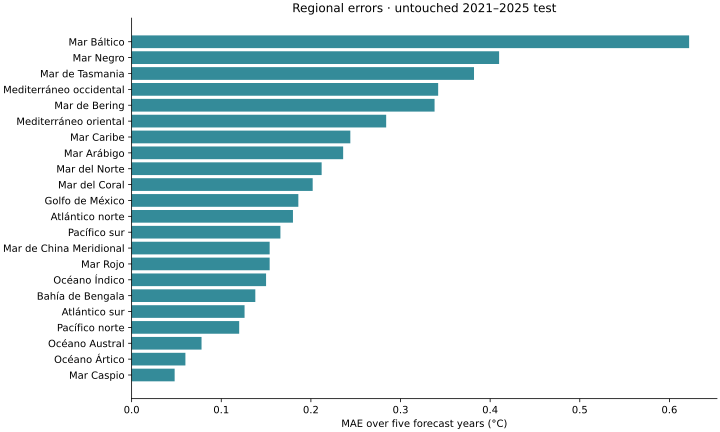

In [6]:
print("Selected:", report["selectedModel"]["id"])
display(pd.DataFrame([{"model": k, **v} for k, v in report["baselineHoldout"].items()]).round(4))
display(pd.DataFrame(report["byHorizon"]).T[["mae", "rmse", "bias", "coverage", "meanIntervalWidth", "calibrationN", "n"]].round(4))
print(f"Pooled final MAE: {report['holdout']['mae']:.3f} °C; achieved coverage: {report['holdout']['coverage']:.1%}, versus nominal 90%.")
display(SVG(filename=str(ROOT / "reports/temperature/regional_errors.svg")))

## 6. Published prediction contract and provenance

110 reviewed predictions: 22 regions × five annual horizons, 2026–2030. The website reads this static artifact; it does not train in the browser. Imputed zones are not presented as observed training data or given invented forecasts. CSV exports separate future values and intervals from history.

The baseline is fully specified by formula, cutoff, sources and run hashes; an opaque serialized model is unnecessary.

In [7]:
snapshot = json.loads((ROOT / "src/data/temperatureForecasts.json").read_text())
forecast = pd.DataFrame(snapshot["records"])
assert len(forecast) == 110
assert sorted(forecast.year.unique()) == list(range(2026, 2031))
assert snapshot["runId"] == report["runId"]
assert (forecast.lower <= forecast.celsius).all() and (forecast.celsius <= forecast.upper).all()
display(forecast[forecast.areaId.isin(["med-west", "caspian"])])
print("Cutoff:", snapshot["trainedThrough"], "· selected model:", snapshot["model"], "· run:", snapshot["runId"])

Cutoff: 2025 · selected model: persistence · run: d384abb90341f47a


,areaId,year,horizon,celsius,lower,upper
9,caspian,2026,1,16.04,15.66,16.42
14,med-west,2026,1,20.24,19.86,20.62
31,caspian,2027,2,16.04,15.55,16.53
36,med-west,2027,2,20.24,19.75,20.73
53,caspian,2028,3,16.04,15.61,16.47
58,med-west,2028,3,20.24,19.81,20.67
75,caspian,2029,4,16.04,15.56,16.52
80,med-west,2029,4,20.24,19.76,20.72
97,caspian,2030,5,16.04,15.60,16.48
102,med-west,2030,5,20.24,19.80,20.68


## 7. Conclusion and limits

Persistence wins development with MAE ≈0.203 °C. The untouched 2021–2025 test gives MAE ≈0.220 °C and pooled interval coverage ≈87%, below nominal 90%. The tested learned models do not justify replacing the simple reference under this protocol. This negative result is part of the deliverable.

Main weaknesses: 22 coarse regions, only one final five-year window, dependent errors, current reconstruction vintages, sparse five-year calibration, no exogenous climate drivers or physical transport model. Geographic features do not establish causality. Predictions are experimental regional statistics and cannot establish local weather, species behavior or a verified climate scenario.

A next experiment should use more monthly/local data, independent data vintages and explicit climate predictors. It requires a new predeclared protocol and a fresh untouched evaluation period; repeatedly selecting against this final test would contaminate it.

**Reproduction:** install `./python[forecast,analysis]`; run `ocean_pipeline.forecast --check`, `ocean_pipeline.forecast_analysis`, then `ocean_pipeline.execute_notebook`, all with `PYTHONPATH=python`. Ordinary Python cells can also be run in Jupyter. CI checks numerical drift and executes all cells.

See [methodology](../docs/temperature-forecast.md), [generated report](../reports/temperature/REPORT.md), and the source hash manifest in `metrics.json`.